In [1]:
import pandas as pd
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import rv_continuous
from scipy.interpolate import interp1d
from astropy import units as u
import astropy.coordinates as ac
from astropy.io import fits

First, we load the isochrone grids. We have one with the DECALS g band for the initial sampling (this is the band where we have a star count of Pal5 to compare to), one for the HST bands (post-2021) and one for the CFHT bands (pre-2014). 

Grid ranges:\
Age: 8-12 Gyr (steps of 1 Gyr)\
Fe/H: -2.99 - -0.5 (steps of 0.5)\
= 35 isochrones total

Fielder 2023 limits: Age > 1.5 Gyr and M/H < -0.57

In [2]:
def read_isochrone_file(filename):
    """
    Reads a .dat file containing multiple isochrone tables and returns
    a dictionary of pandas DataFrames keyed by (Zini, logAge).
    """

    with open(filename, "r") as f:
        lines = f.readlines()

    # Remove the global header (first 13 lines)
    lines = lines[13:-1]

    isochrones = {}
    current_header = None
    current_block = []

    for line in lines:
        if line.startswith("# Zini"):
            # Save previous isochrone if present
            if current_header is not None and current_block:
                df = pd.read_csv(
                    StringIO("".join(current_block)),
                    sep="\\s+",
                    comment="#",
                    names=current_header
                )
                df.drop(df.tail(2).index,inplace=True)
                zini = df.iloc[0]["Zini"]
                FeH = np.round(np.log10(zini/0.0158), 2)
                logage = df.iloc[0]["logAge"]
                age_name = np.round((10 ** logage)/1e9, 2)
                key = f"FeH_{FeH}_Age_{age_name}Gyr"

                isochrones[key] = df
                print(f"mass range of {key}: {df['Mini'].min()} - {df['Mini'].max()} Msun")

            # Start new isochrone
            current_header = line.lstrip("#").split()
            current_block = []

        else:
            # Data line
            if line.strip() and not line.startswith("#"):
                current_block.append(line)

    # Save final isochrone
    if current_header is not None and current_block:
        df = pd.read_csv(
            StringIO("".join(current_block)),
            sep="\\s+",
            comment="#",
            names=current_header
        )
        df.drop(df.tail(2).index,inplace=True)

        zini = df.iloc[0]["Zini"]
        FeH = np.round(np.log10(zini/0.0158), 2)
        logage = df.iloc[0]["logAge"]
        age_name = np.round((10 ** logage)/1e9, 2)
        key = f"FeH_{FeH}_Age_{age_name}Gyr"

        isochrones[key] = df

    return isochrones


In [3]:
isochrones_HST = read_isochrone_file("../isochrones_all_HST.dat")
isochrones_CFHT = read_isochrone_file("../isochrones_all_CFHT.dat")
isochrones_DECAM = read_isochrone_file("../isochrones_all_DECAM.dat")

mass range of FeH_-1.31_Age_11.3Gyr: 0.0900000036 - 0.8326520324 Msun
mass range of FeH_-3.0_Age_8.0Gyr: 0.1000000015 - 0.9020699859 Msun
mass range of FeH_-3.0_Age_9.0Gyr: 0.1000000015 - 0.8710916042 Msun
mass range of FeH_-3.0_Age_10.0Gyr: 0.1000000015 - 0.8442974091 Msun
mass range of FeH_-3.0_Age_11.0Gyr: 0.1000000015 - 0.8210436702 Msun
mass range of FeH_-3.0_Age_12.0Gyr: 0.1000000015 - 0.8003745675 Msun
mass range of FeH_-2.5_Age_8.0Gyr: 0.1000000015 - 0.9020699859 Msun
mass range of FeH_-2.5_Age_9.0Gyr: 0.1000000015 - 0.8710916042 Msun
mass range of FeH_-2.5_Age_10.0Gyr: 0.1000000015 - 0.8442974091 Msun
mass range of FeH_-2.5_Age_11.0Gyr: 0.1000000015 - 0.8210436702 Msun
mass range of FeH_-2.5_Age_12.0Gyr: 0.1000000015 - 0.8003745675 Msun
mass range of FeH_-2.0_Age_8.0Gyr: 0.0933015496 - 0.9036912322 Msun
mass range of FeH_-2.0_Age_9.0Gyr: 0.0933015496 - 0.8726873398 Msun
mass range of FeH_-2.0_Age_10.0Gyr: 0.0933015496 - 0.8459330797 Msun
mass range of FeH_-2.0_Age_11.0Gyr: 0.0

In [4]:
# drop the last 5 isochrones in all three datasets (error in metallicity)
for key in list(isochrones_HST.keys())[-5:]:
    del isochrones_HST[key]
    del isochrones_CFHT[key]
    del isochrones_DECAM[key] 

len(isochrones_HST),isochrones_HST.keys()

(31,
 dict_keys(['FeH_-1.31_Age_11.3Gyr', 'FeH_-3.0_Age_8.0Gyr', 'FeH_-3.0_Age_9.0Gyr', 'FeH_-3.0_Age_10.0Gyr', 'FeH_-3.0_Age_11.0Gyr', 'FeH_-3.0_Age_12.0Gyr', 'FeH_-2.5_Age_8.0Gyr', 'FeH_-2.5_Age_9.0Gyr', 'FeH_-2.5_Age_10.0Gyr', 'FeH_-2.5_Age_11.0Gyr', 'FeH_-2.5_Age_12.0Gyr', 'FeH_-2.0_Age_8.0Gyr', 'FeH_-2.0_Age_9.0Gyr', 'FeH_-2.0_Age_10.0Gyr', 'FeH_-2.0_Age_11.0Gyr', 'FeH_-2.0_Age_12.0Gyr', 'FeH_-1.5_Age_8.0Gyr', 'FeH_-1.5_Age_9.0Gyr', 'FeH_-1.5_Age_10.0Gyr', 'FeH_-1.5_Age_11.0Gyr', 'FeH_-1.5_Age_12.0Gyr', 'FeH_-1.0_Age_8.0Gyr', 'FeH_-1.0_Age_9.0Gyr', 'FeH_-1.0_Age_10.0Gyr', 'FeH_-1.0_Age_11.0Gyr', 'FeH_-1.0_Age_12.0Gyr', 'FeH_-0.5_Age_8.0Gyr', 'FeH_-0.5_Age_9.0Gyr', 'FeH_-0.5_Age_10.0Gyr', 'FeH_-0.5_Age_11.0Gyr', 'FeH_-0.5_Age_12.0Gyr']))

In Pearson2019 they sample based on 3000 stars in the CFHT g-band, citing Bonaca2020. However, Bonanca2020 uses DECAM data to count 3000 stars in the g-band. They are almost the same, but not entirely (see figures "CFHT-DECAM_isochrone_comparison"). So for good measure, we use the DECAM for counting.

In [5]:
isochrones_HST['FeH_-3.0_Age_8.0Gyr'].head()

,Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,...,Cexcess,Z,mbolmag,F435Wmag,F475Wmag,F555Wmag,F606Wmag,F625Wmag,F775Wmag,F814Wmag
0,0.000016,-2.19174,9.90309,0.100000,1.171106,0.100,-2.784,3.5581,5.407,1,...,-1.0,0.0001,11.731,14.267,13.690,12.847,12.233,11.868,11.004,10.880
1,0.000016,-2.19174,9.90309,0.109821,1.248275,0.109,-2.636,3.5735,5.358,1,...,-1.0,0.0001,11.359,13.710,13.164,12.384,11.806,11.455,10.664,10.547
2,0.000016,-2.19174,9.90309,0.129464,1.378675,0.129,-2.396,3.5960,5.280,1,...,-1.0,0.0001,10.759,12.809,12.307,11.629,11.131,10.813,10.100,9.994
3,0.000016,-2.19174,9.90309,0.149107,1.485596,0.149,-2.236,3.6074,5.228,1,...,-1.0,0.0001,10.360,12.279,11.796,11.157,10.695,10.395,9.710,9.609
4,0.000016,-2.19174,9.90309,0.168750,1.575614,0.168,-2.112,3.6147,5.186,1,...,-1.0,0.0001,10.049,11.892,11.420,10.802,10.361,10.070,9.402,9.304


In [6]:
# Using scipy to randomly sample from a custom distribution requires us to set it as a subclass
class PowerLawPDF(rv_continuous):
    def _pdf(self, m, expo):
        a, b = self.a, self.b # set limits because they don't occur naturally in powerlaw 
        return m**(-expo) / ((b**(1-expo) - a**(1-expo)) / (1-expo)) #normalised 

expo = 0.5 #exponent, required to be > 0, so move the sign to the pdf definition
a, b = 0.01, 120 #M_sol
a_iso, b_iso = 0.09, 1.2 #M_sol
ms = np.linspace(a, b, 1000) #mass range for plotting
imf = PowerLawPDF(a=a_iso, b=b_iso, name='iso_imf')

# this is now normalised to the full distribution. We need a separate one for each isochrone, since they have different mass ranges. 
# However, the mass ranges are similar, so we approximate the limits in the imf, and discard any edge samples that fall outside those limits. 



We then sample a large stellar population from an IMF, and save it to a txt file so we don't have to do it every time. 

In [7]:
# generate samples from the distribution
#samples = imf.rvs(expo = expo, size=int(1e7))
#np.savetxt('imf_samples_1e7.txt', np.array(samples))

#1e6 samples took 2 mins
#1e7 samples took 82 mins / 23 mins

In [8]:
samples = np.loadtxt('../imf_samples_1e7.txt')

Creating an interpolator for all the isochrones, so we can get the brightness of an arbitrary stellar mass. 

From the interpolated isochrones, we make a new df with the sampled stars and their brightness in the various bands, for each isohrone.

In [9]:
isochrones_sampled = {}

for key in isochrones_DECAM.keys():
    sample_df = pd.DataFrame(samples, columns=["mass"])

    # valid mass overlap for this isochrone key
    ranges = [
        (isochrones_DECAM[key].Mini.min(), isochrones_DECAM[key].Mini.max()),
        (isochrones_HST[key].Mini.min(),   isochrones_HST[key].Mini.max()),
        (isochrones_CFHT[key].Mini.min(),  isochrones_CFHT[key].Mini.max()),
    ]
    m_min = max(r[0] for r in ranges)
    m_max = min(r[1] for r in ranges)

    sample_df = sample_df[
        (sample_df["mass"] >= m_min) & (sample_df["mass"] <= m_max)].copy()

    interDECAMg = interp1d(isochrones_DECAM[key].Mini, isochrones_DECAM[key].gmag)
    interHST555 = interp1d(isochrones_HST[key].Mini, isochrones_HST[key].F555Wmag)
    interHST814 = interp1d(isochrones_HST[key].Mini, isochrones_HST[key].F814Wmag)
    interHST475 = interp1d(isochrones_HST[key].Mini, isochrones_HST[key].F475Wmag)
    interCFHTg  = interp1d(isochrones_CFHT[key].Mini, isochrones_CFHT[key]["g*mag"])
    interCFHTi  = interp1d(isochrones_CFHT[key].Mini, isochrones_CFHT[key]["i*mag"])
    interCFHTu  = interp1d(isochrones_CFHT[key].Mini, isochrones_CFHT[key]["u*mag"])
    interCFHTr  = interp1d(isochrones_CFHT[key].Mini, isochrones_CFHT[key]["r*mag"])
    interCFHTz  = interp1d(isochrones_CFHT[key].Mini, isochrones_CFHT[key]["z*mag"])

    sample_df["CumSum_mass"] = np.cumsum(sample_df["mass"])
    sample_df["DECAMg"] = interDECAMg(sample_df["mass"])
    sample_df["HST555"] = interHST555(sample_df["mass"])
    sample_df["HST814"] = interHST814(sample_df["mass"])
    sample_df["HST475"] = interHST475(sample_df["mass"])
    sample_df["CFHTg"]  = interCFHTg(sample_df["mass"])
    sample_df["CFHTi"]  = interCFHTi(sample_df["mass"])
    sample_df["CFHTu"]  = interCFHTu(sample_df["mass"])
    sample_df["CFHTr"]  = interCFHTr(sample_df["mass"])
    sample_df["CFHTz"]  = interCFHTz(sample_df["mass"])


    isochrones_sampled[key] = sample_df

print(list(isochrones_sampled.keys()))


['FeH_-1.31_Age_11.3Gyr', 'FeH_-3.0_Age_8.0Gyr', 'FeH_-3.0_Age_9.0Gyr', 'FeH_-3.0_Age_10.0Gyr', 'FeH_-3.0_Age_11.0Gyr', 'FeH_-3.0_Age_12.0Gyr', 'FeH_-2.5_Age_8.0Gyr', 'FeH_-2.5_Age_9.0Gyr', 'FeH_-2.5_Age_10.0Gyr', 'FeH_-2.5_Age_11.0Gyr', 'FeH_-2.5_Age_12.0Gyr', 'FeH_-2.0_Age_8.0Gyr', 'FeH_-2.0_Age_9.0Gyr', 'FeH_-2.0_Age_10.0Gyr', 'FeH_-2.0_Age_11.0Gyr', 'FeH_-2.0_Age_12.0Gyr', 'FeH_-1.5_Age_8.0Gyr', 'FeH_-1.5_Age_9.0Gyr', 'FeH_-1.5_Age_10.0Gyr', 'FeH_-1.5_Age_11.0Gyr', 'FeH_-1.5_Age_12.0Gyr', 'FeH_-1.0_Age_8.0Gyr', 'FeH_-1.0_Age_9.0Gyr', 'FeH_-1.0_Age_10.0Gyr', 'FeH_-1.0_Age_11.0Gyr', 'FeH_-1.0_Age_12.0Gyr', 'FeH_-0.5_Age_8.0Gyr', 'FeH_-0.5_Age_9.0Gyr', 'FeH_-0.5_Age_10.0Gyr', 'FeH_-0.5_Age_11.0Gyr', 'FeH_-0.5_Age_12.0Gyr']


In [10]:
isochrones_sampled['FeH_-1.31_Age_11.3Gyr']

,mass,CumSum_mass,DECAMg,HST555,HST814,HST475,CFHTg,CFHTi,CFHTu,CFHTr,CFHTz
2,0.229280,2.292802e-01,11.447772,10.863854,9.035829,11.637259,11.399943,9.554144,13.439527,10.152764,9.295856
4,0.685787,9.150673e-01,5.852221,5.672007,4.921357,5.987331,5.839000,5.361468,6.548422,5.484682,5.335805
5,0.438031,1.353099e+00,9.322656,8.868983,7.391906,9.492626,9.281686,7.884846,10.963853,8.311430,7.697025
6,0.257520,1.610619e+00,11.104152,10.539062,8.762591,11.290550,11.057302,9.276839,13.039871,9.846274,9.028944
7,0.437472,2.048091e+00,9.329419,8.875235,7.396725,9.499450,9.288414,7.889761,10.971884,8.316990,7.701654
...,...,...,...,...,...,...,...,...,...,...,...
9999994,0.339316,3.071130e+06,10.373262,9.846774,8.174594,10.553903,10.328835,8.681449,12.200442,9.197432,8.453312
9999995,0.375015,3.071131e+06,10.038489,9.532231,7.914734,10.216127,9.995276,8.417586,11.810198,8.907908,8.201031
9999996,0.109628,3.071131e+06,14.426470,13.677866,11.102609,14.666261,14.382459,11.685849,17.219175,12.815023,11.268474
9999998,0.172838,3.071131e+06,12.330139,11.694582,9.717589,12.528572,12.279781,10.248059,14.486318,10.941173,9.959045


From here we have two options to limit the stellar populations and their mass.

We can use the Pal5 DECACM g-band to count up until we have the nx3000 stars between g = 20 and g = 23 mag, and say that that translates to n x Pal5 mass. 

Or we can count up to different masses. This would then correspond to $M_{samp} = M_{prog,ini} * (M_{stream}/(M_{stream}+M_{prog,disr}))$. So this way, we could either know something about the total, initial mass, with an assumed mass los (which can perhaps be approximated from the brightness ratio), or get the mass loss with an assumed mass. 



First, lets define some geometrics and a hekfunction to sum magnitudes. 

In [11]:
d_mod_pal5 = 16.8553
d_pal5 = 10**((d_mod_pal5)/5+1)*u.pc # distance of Pal 5 in pc
area_mask = 2*8.00# arcsec^2, imported from previous script. Change with new masks
area_P19_pc = (0.414*u.kpc*u.kpc).to(u.pc*u.pc) #The area of Pal5 listed in Pearson19 in kpc^2
area_P19_arcsec = area_P19_pc / d_pal5**2 *(u.rad.to(u.arcsec))**2

d_dw = 35.2 * u.Mpc # distance of the stream in Mpc
d_mod_dw = 5 * np.log10((d_dw.to(u.pc) / 10 *u.pc).value)

In [12]:
# to get the surface brightness, we first sum the magnitudes in each band (as flux)
# then we convert the total flux to a magnitude, and "divide" by the area in arcsec^2
def surface_brightness(stars, area):
    tot_flux = np.sum(10**(-0.4*stars))
    tot_mag = -2.5 * np.log10(tot_flux)
    return tot_mag + 2.5 * np.log10(area) # in mag/arcsec^2

def total_brightness(stars, area):
    tot_flux = np.sum(10**(-0.4*stars))
    tot_mag = -2.5 * np.log10(tot_flux)
    return tot_mag # in mag

#### Assuming mass-loss like Pal-5:

In [13]:
multiplier = 20
target_count = multiplier * 3000
rows = []

for key, df in isochrones_sampled.items():
    # Selection defined from DECAM data
    sel = df[(df["DECAMg"] > 20 - d_mod_pal5) & (df["DECAMg"] < 23 - d_mod_pal5)]

    if len(sel) < target_count:
        print('In key', key, 'only', len(sel), 'stars meet the DECAM selection criteria. Skipping.')
        continue

    max_id = sel.iloc[target_count - 1].name
    full_pop = df.loc[:max_id]
    #print(f'key: {key}, total mass: {df.loc[max_id, "CumSum_mass"]:.2f} M_sol, N_stars: {len(full_pop)}')

    rows.append({
        "key": key,
        "n_sel_decam": len(sel),
        "sb_DECAMg": surface_brightness(full_pop["DECAMg"], area_mask)+d_mod_dw,
        "sb_HST555": surface_brightness(full_pop["HST555"], area_mask)+d_mod_dw,
        "sb_HST814": surface_brightness(full_pop["HST814"], area_mask)+d_mod_dw,
        "sb_CFHTu":  surface_brightness(full_pop["CFHTu"],  area_mask)+d_mod_dw,
        "sb_CFHTg":  surface_brightness(full_pop["CFHTg"],  area_mask)+d_mod_dw,
        "sb_CFHTr":  surface_brightness(full_pop["CFHTr"],  area_mask)+d_mod_dw,
        "sb_CFHTi":  surface_brightness(full_pop["CFHTi"],  area_mask)+d_mod_dw,
        "sb_CFHTz":  surface_brightness(full_pop["CFHTz"],  area_mask)+d_mod_dw,
        "total_mass": df.loc[max_id, "CumSum_mass"]
    })

sb_df = pd.DataFrame(rows).sort_values("key").reset_index(drop=True)



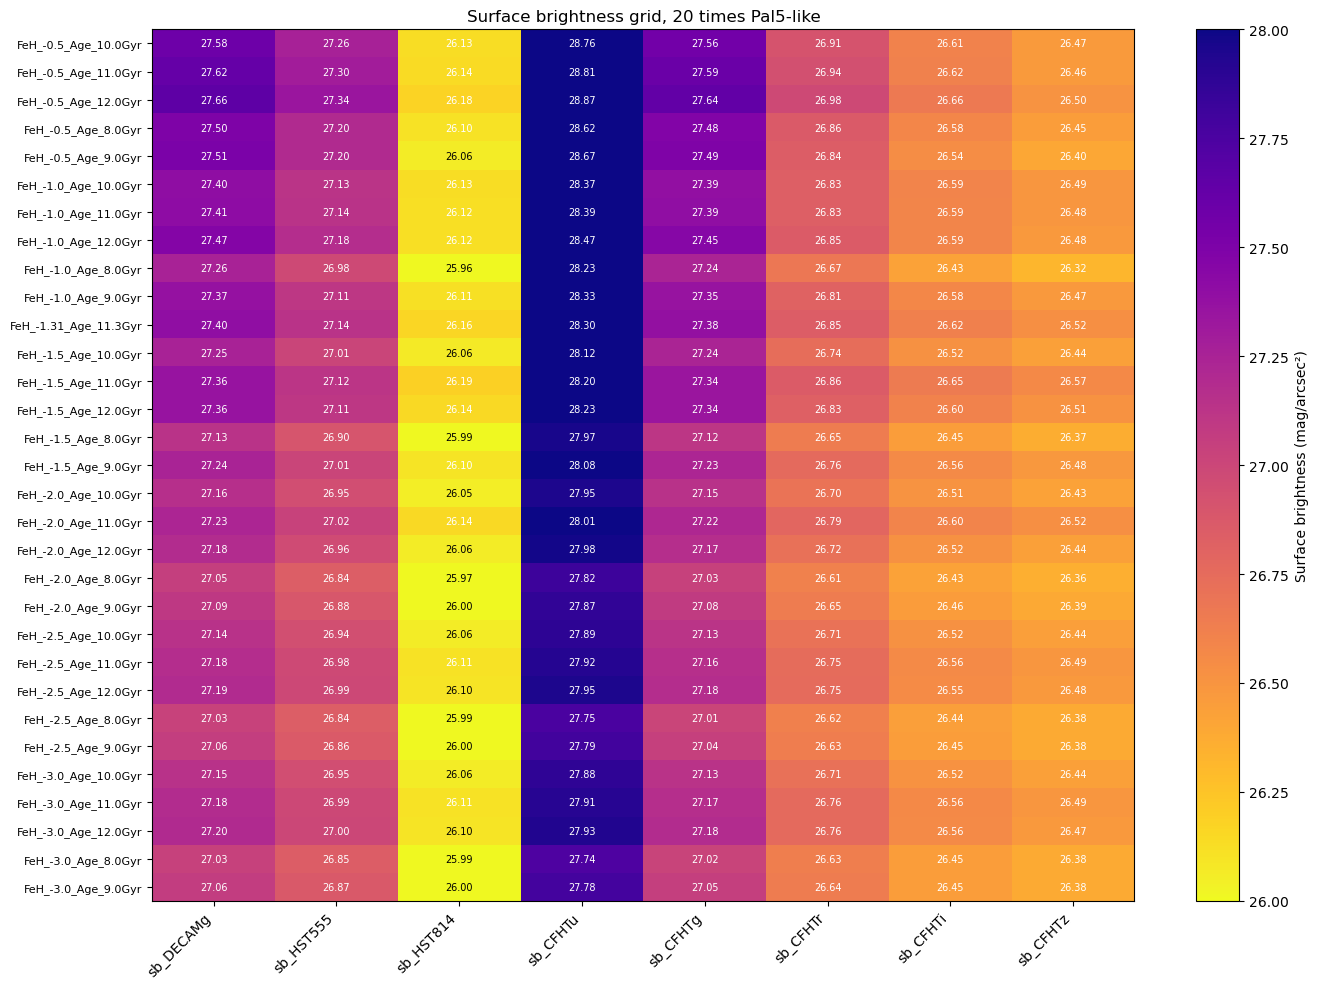

In [14]:
# columns to plot
sb_cols = ["sb_DECAMg", "sb_HST555", "sb_HST814",
           "sb_CFHTu", "sb_CFHTg", "sb_CFHTr", "sb_CFHTi", "sb_CFHTz"]

plot_df = sb_df.set_index("key")[sb_cols]

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(plot_df.values, aspect="auto", vmin=26, vmax=28, cmap="plasma_r")

# axis labels
ax.set_xticks(range(len(sb_cols)))
ax.set_xticklabels(sb_cols, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=8)

# annotate each cell with its value
for i in range(len(plot_df)):
    for j in range(len(sb_cols)):
        val = plot_df.values[i, j]
        text = f"{val:.2f}" if not np.isnan(val) else "—"
        ax.text(j, i, text, ha="center", va="center", fontsize=7,
                color="white" if val>26.1 else "k")

plt.colorbar(im, ax=ax, label="Surface brightness (mag/arcsec²)")
ax.set_title(f"Surface brightness grid, {multiplier} times Pal5-like")
plt.tight_layout()

In [15]:
# print the sb in F814W for 'FeH_-1.5_Age_11.0Gyr'
pal5_20_totmass = sb_df[sb_df["key"] == "FeH_-1.31_Age_11.3Gyr"].total_mass.values
print(sb_df[sb_df["key"] == "FeH_-1.31_Age_11.3Gyr"])

                      key  n_sel_decam  sb_DECAMg  sb_HST555  sb_HST814  \
10  FeH_-1.31_Age_11.3Gyr      1174821  27.397999  27.139172  26.159413   

     sb_CFHTu   sb_CFHTg   sb_CFHTr   sb_CFHTi   sb_CFHTz     total_mass  
10  28.300908  27.380147  26.851055  26.621153  26.524625  157275.188911  


In [16]:
(pal5_20_totmass/0.75)/2e6

array([0.10485013])

#### Assuming 3/2 mass ratio (replace with brightness ratio)

On mass selection. 

Ibata (2017, sec 5.2) calculate for Pal5 a total mass of 1.2e4 M_sun, and that only 4.3e3 M_sun are left in the cluster remnant. They also note that the imf is very shallow, hinting at primarily loss of low-mass stars. Price-Whelan (2019, p6) get a total mass of 9e4 Msun. This allows for pal5 tails to contain up to 9e4-4.3e3 M_sun.s

In [17]:
total_pal5_ibata = 1.2e4
total_pal5_pw = 9e4
cluster_remnant = 4.3e3
stream_pal5_ibata = total_pal5_ibata - cluster_remnant
stream_pal5_pw = total_pal5_pw - cluster_remnant

stream_pal5_pw, stream_pal5_ibata,(stream_pal5_pw/total_pal5_pw), (stream_pal5_ibata/total_pal5_ibata)

(85700.0, 7700.0, 0.9522222222222222, 0.6416666666666667)

In [18]:
sb_df[sb_df["key"] == "FeH_-1.31_Age_11.3Gyr"].total_mass.values/stream_pal5_pw

array([1.83518307])

In [19]:
mass_ratio = 0.75 # stream/prog_ini
ini_prog_mass = 1.65e5 #Msun
#We can also just set the ratio to 1 and use this as a straight mass counter in any population, e.g. stars in the stream
stream_mass = ini_prog_mass * mass_ratio
print('The requested stream mass is', stream_mass, 'Msun, over an area of', area_mask, 'arcsec^2.')
rows = []
#area_mask=8

for key, df in isochrones_sampled.items():
    stream = isochrones_sampled[key][isochrones_sampled[key]['CumSum_mass'] <= stream_mass]
    if len(stream)==len(df):
        print('In key', key, 'the requested stream mass is greater than the available samples. Skipping.')
        continue
    rows.append({
        "key": key,
        "n_sel_decam": len(stream),
        #"sb_DECAMg": surface_brightness(stream["DECAMg"], area_mask)+d_mod_dw,
        "sb_HST555": surface_brightness(stream["HST555"], area_mask)+d_mod_dw,
        "sb_HST814": surface_brightness(stream["HST814"], area_mask)+d_mod_dw,
        "sb_CFHTu":  surface_brightness(stream["CFHTu"],  area_mask)+d_mod_dw,
        "sb_CFHTg":  surface_brightness(stream["CFHTg"],  area_mask)+d_mod_dw,
        "sb_CFHTr":  surface_brightness(stream["CFHTr"],  area_mask)+d_mod_dw,
        "sb_CFHTi":  surface_brightness(stream["CFHTi"],  area_mask)+d_mod_dw,
        "sb_CFHTz":  surface_brightness(stream["CFHTz"],  area_mask)+d_mod_dw,
        "tot_HST555": total_brightness(stream["HST555"], area_mask)+d_mod_dw,
        "tot_HST814": total_brightness(stream["HST814"], area_mask)+d_mod_dw,
    })

sb_df_mass = pd.DataFrame(rows).sort_values("key").reset_index(drop=True)

sb_df_mass.head()


The requested stream mass is 123750.0 Msun, over an area of 16.0 arcsec^2.


,key,n_sel_decam,sb_HST555,sb_HST814,sb_CFHTu,sb_CFHTg,sb_CFHTr,sb_CFHTi,sb_CFHTz,tot_HST555,tot_HST814
0,FeH_-0.5_Age_10.0Gyr,280661,27.546047,26.408485,29.041835,27.840669,27.190186,26.885961,26.742608,24.535747,23.398185
1,FeH_-0.5_Age_11.0Gyr,287224,27.625248,26.465958,29.150479,27.926318,27.261353,26.945753,26.795582,24.614948,23.455658
2,FeH_-0.5_Age_12.0Gyr,293146,27.739562,26.582113,29.260330,28.037498,27.380467,27.062533,26.910718,24.729262,23.571813
3,FeH_-0.5_Age_8.0Gyr,266158,27.390190,26.304109,28.806900,27.667222,27.056577,26.777023,26.647272,24.379890,23.293809
4,FeH_-0.5_Age_9.0Gyr,273827,27.435154,26.298546,28.914561,27.727161,27.082248,26.776524,26.631637,24.424854,23.288246


In [20]:
sb_df_mass[sb_df_mass['key']=='FeH_-1.0_Age_8.0Gyr'].n_sel_decam

8    280654
Name: n_sel_decam, dtype: int64

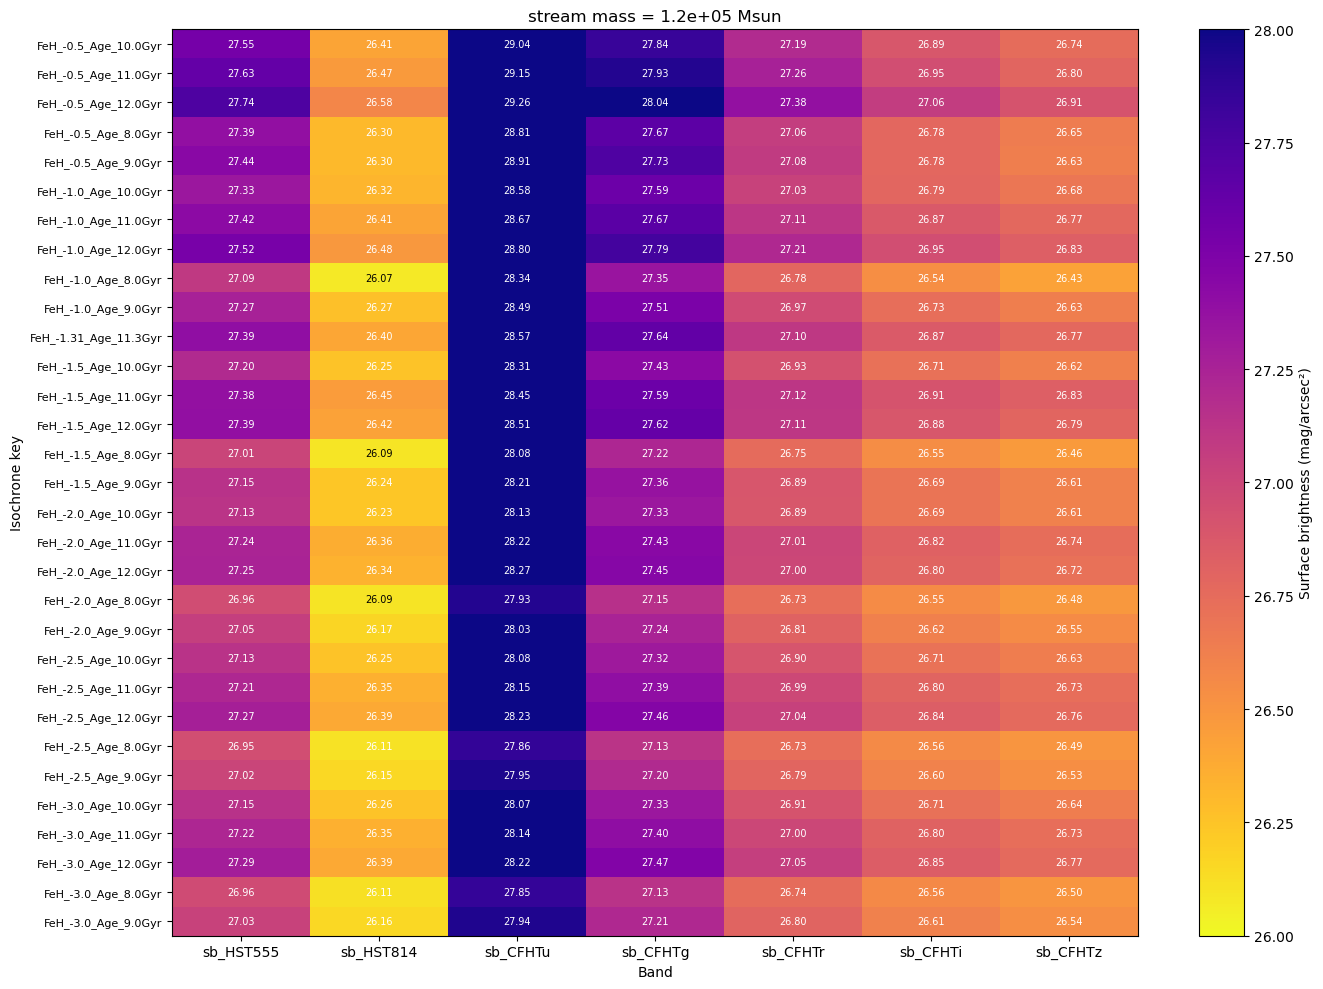

In [22]:
# columns to plot
sb_cols = [ "sb_HST555", "sb_HST814",
           "sb_CFHTu", "sb_CFHTg", "sb_CFHTr", "sb_CFHTi", "sb_CFHTz"]

plot_df = sb_df_mass.set_index("key")[sb_cols]

fig, ax = plt.subplots(figsize=(14, 10))#, facecolor="none")
#ax.set_facecolor("none")

im = ax.imshow(plot_df.values, aspect="auto", vmin=26, vmax=28, cmap="plasma_r")

# axis labels
ax.set_xticks(range(len(sb_cols)))
ax.set_xticklabels(sb_cols, rotation=0, ha="center", fontsize=10, color="k")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=8, color="k")
ax.set_xlabel("Band", color="k")
ax.set_ylabel("Isochrone key", color="k")
ax.tick_params(axis="both", colors="k")

# annotate each cell with its value
for i in range(len(plot_df)):
    for j in range(len(sb_cols)):
        val = plot_df.values[i, j]
        text = f"{val:.2f}" if not np.isnan(val) else "—"
        ax.text(j, i, text, ha="center", va="center", fontsize=7,
                color="white" if val>26.1 else "k")

cbar = plt.colorbar(im, ax=ax, label="Surface brightness (mag/arcsec²)")
cbar.ax.yaxis.set_tick_params(color="k")
plt.setp(cbar.ax.get_yticklabels(), color="k")
cbar.set_label("Surface brightness (mag/arcsec²)", color="k")

ax.set_title(f"stream mass = {stream_mass:.1e} Msun", color="k")
plt.tight_layout()


## Assigning mass and brightness to stars from simulation

From the X-stream simulated stream I can get positions of the stars in the stream tails, and using the IMF and isochrone sampling from above, I can assign each a set of stellar parameters such as mass and brightness in different bands. This will be used to mock-omserve the modelled streams.

In [26]:
# three model streams
stream_105 = np.load('../Xstream_points/UDG_stream_dict_lowbound.npy')
stream_106 = np.load('../Xstream_points/UDG_stream_dict_20xPal5.npy')
stream_107 = np.load('../Xstream_points/UDG_stream_dict_dwarf.npy')
print(len(stream_105), len(stream_106), len(stream_107)) #populated with 6e4, 7e5, 7e5 stars

280000 1169998 1170000


In [27]:
stars_106 = pd.DataFrame(stream_106, columns=['x_pos', 'y_pos', 'z_pos', 'x_vel', 'y_vel', 'z_vel'])
stars_107 = pd.DataFrame(stream_107, columns=['x_pos', 'y_pos', 'z_pos', 'x_vel', 'y_vel', 'z_vel'])
stars_105 = pd.DataFrame(stream_105, columns=['x_pos', 'y_pos', 'z_pos', 'x_vel', 'y_vel', 'z_vel'])
len(stars_106), len(stars_107), len(stars_105)

(1169998, 1170000, 280000)

In [28]:
def attach_stars(DF, isochrone_key = "FeH_-1.0_Age_8.0Gyr"): #pal5 for this one
    nr_stars = len(DF)
    
    isochrone = isochrones_sampled[isochrone_key].reset_index(drop=True)
    
    DF['mass'] = isochrone['mass'][:nr_stars]
    DF['HST555'] = isochrone['HST555'][:nr_stars]
    DF['HST814'] = isochrone['HST814'][:nr_stars]
    DF['CFHTg']  = isochrone['CFHTg'][:nr_stars]
    DF['CFHTi']  = isochrone['CFHTi'][:nr_stars]
    DF['CFHTu']  = isochrone['CFHTu'][:nr_stars]
    DF['CFHTr']  = isochrone['CFHTr'][:nr_stars]
    DF['CFHTz']  = isochrone['CFHTz'][:nr_stars]
    return DF

attach_stars(stars_105, isochrone_key = "FeH_-1.0_Age_8.0Gyr")
attach_stars(stars_106, isochrone_key = "FeH_-1.31_Age_11.3Gyr")
attach_stars(stars_107, isochrone_key = "FeH_-1.31_Age_11.3Gyr")
stars_106.head()


,x_pos,y_pos,z_pos,x_vel,y_vel,z_vel,mass,HST555,HST814,CFHTg,CFHTi,CFHTu,CFHTr,CFHTz
0,1.981322,1.513710,-0.726677,0.071837,0.015106,-0.111524,0.229280,10.863854,9.035829,11.399943,9.554144,13.439527,10.152764,9.295856
1,-1.424911,-0.816921,0.951183,0.125079,0.132643,0.040810,0.685787,5.672007,4.921357,5.839000,5.361468,6.548422,5.484682,5.335805
2,1.735285,1.273224,-0.766472,0.075076,0.007386,-0.135823,0.438031,8.868983,7.391906,9.281686,7.884846,10.963853,8.311430,7.697025
3,2.142339,1.473420,-1.483797,0.026097,-0.015779,-0.096164,0.257520,10.539062,8.762591,11.057302,9.276839,13.039871,9.846274,9.028944
4,0.101184,0.514174,0.884447,0.187210,0.140634,-0.067148,0.437472,8.875235,7.396725,9.288414,7.889761,10.971884,8.316990,7.701654


In [29]:
stars_106.mass.sum(),stars_107.mass.sum(), stars_105.mass.sum()

(466689.71481453587, 466690.81643208663, 123462.7996987841)

In [32]:
import sys
import os
sys.path.append('../scripts')
from psf_utilities import download_psf_model

psfs_dir = '/Users/lkb234/Library/CloudStorage/OneDrive-UniversityofCopenhagen/GC_stream_9050dw/Dataanalysis/'+'psfs/'

hst_wfc3_f555w_psf_model = download_psf_model(psfs_dir, 'WFC3UV', 'F555W')
hst_wfc3_f814w_psf_model = download_psf_model(psfs_dir, 'WFC3UV', 'F814W')
hdulpsf_555 = fits.open(psfs_dir+hst_wfc3_f555w_psf_model, ignore_missing_end=True)
hdulpsf_814 = fits.open(psfs_dir+hst_wfc3_f814w_psf_model, ignore_missing_end=True)
hdulpsf_555.info()

#slic = 10
#PSF_555 = hdulpsf_555[0].data[slic]/np.sum(hdulpsf_555[0].data[slic]) #normalise the psf
#PSF_814 = hdulpsf_814[0].data[slic]/np.sum(hdulpsf_814[0].data[slic])

Validation complete, the PSF file is readable.
Validation complete, the PSF file is readable.
Filename: /Users/lkb234/Library/CloudStorage/OneDrive-UniversityofCopenhagen/GC_stream_9050dw/Dataanalysis/psfs/STDPSF_WFC3UV_F555W.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (101, 101, 56)   float32   


        Use textwrap.indent() instead. [astropy.io.fits.hdu.hdulist]
    Header size is not multiple of 2880: 1
There may be extra bytes after the last HDU or the file is corrupted. [astropy.io.fits.hdu.hdulist]


In [38]:
from scipy.stats import poisson
from scipy.signal import convolve2d

The HST psf consists of 56 tiles that differ slightly across the detector/image. However, luckily for us, the stream is contained within an area small enough that just using that corresponding tile will be a good enough approximation. 
For the same reason, and for our purposes, it is also an acceptable approximation to convolve with the psf after we add the stellar flux to each pixel - the exact placement of each star inside the pixel is not of importance when we are nowhere near resolving individual stars anyway. 

In [39]:
# make a grid of pixels
px_scale = 0.05 #arcsec/pixel
px_size = px_scale*u.arcsec.to(u.rad)*d_dw.to(u.pc) # physical size of a pixel at the distance of the stream
def assign_stars_to_pixels(stars_106, px_size):
    xrange = [stars_106.x_pos.min(), stars_106.x_pos.max()]
    zrange = [stars_106.z_pos.min(), stars_106.z_pos.max()]

    nr_pix_x = int((stars_106.x_pos.max()-stars_106.x_pos.min())/px_size.to(u.kpc).value)
    nr_pix_z = int((stars_106.z_pos.max()-stars_106.z_pos.min())/px_size.to(u.kpc).value)

    # make meshgrid
    x_edges = np.linspace(xrange[0], xrange[1], nr_pix_x)
    z_edges = np.linspace(zrange[0], zrange[1], nr_pix_z)

    # assign each star to a pixel
    stars_106['pix_x'] = np.digitize(stars_106.x_pos, x_edges) - 1
    stars_106['pix_z'] = np.digitize(stars_106.z_pos, z_edges) - 1

    # convert the magnitudes in the two HST bands to fluxes - relative flux is good enough since we will be converting back to magnitudes after convolution
    stars_106['flux_HST555'] = 10**(-0.4*stars_106['HST555'])
    stars_106['flux_HST814'] = 10**(-0.4*stars_106['HST814'])

    #sum the fluxes in each pixel in the X, Z meshgrid
    flux_grid_555 = np.zeros((nr_pix_z, nr_pix_x))
    flux_grid_814 = np.zeros((nr_pix_z, nr_pix_x))

    for _, star in stars_106.iterrows():
        x_idx = int(star['pix_x'])
        z_idx = int(star['pix_z'])
        flux_grid_555[z_idx, x_idx] += star['flux_HST555']
        flux_grid_814[z_idx, x_idx] += star['flux_HST814']
    
    # add poisson noise to the flux in each pixel, with lambda equal to the flux (since flux is proportional to number of photons)
    flux_grid_555 = poisson.rvs(flux_grid_555)
    flux_grid_814 = poisson.rvs(flux_grid_814)
    return flux_grid_555, flux_grid_814, nr_pix_x, nr_pix_z

flux_grid_555_7, flux_grid_814_7, nr_pix_x_7, nr_pix_z_7 = assign_stars_to_pixels(stars_107, px_size)
flux_grid_555_6, flux_grid_814_6, nr_pix_x_6, nr_pix_z_6 = assign_stars_to_pixels(stars_106, px_size)
flux_grid_555_5, flux_grid_814_5, nr_pix_x_5, nr_pix_z_5 = assign_stars_to_pixels(stars_105, px_size)

mag_grid_555_7 = -2.5 * np.log10(flux_grid_555_7) + d_mod_dw
mag_grid_814_7 = -2.5 * np.log10(flux_grid_814_7) + d_mod_dw
mag_grid_555_6 = -2.5 * np.log10(flux_grid_555_6) + d_mod_dw
mag_grid_814_6 = -2.5 * np.log10(flux_grid_814_6) + d_mod_dw
mag_grid_555_5 = -2.5 * np.log10(flux_grid_555_5) + d_mod_dw
mag_grid_814_5 = -2.5 * np.log10(flux_grid_814_5) + d_mod_dw

/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_4044/2657224227.py:42: RuntimeWarning: divide by zero encountered in log10
  mag_grid_555_7 = -2.5 * np.log10(flux_grid_555_7) + d_mod_dw
/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_4044/2657224227.py:43: RuntimeWarning: divide by zero encountered in log10
  mag_grid_814_7 = -2.5 * np.log10(flux_grid_814_7) + d_mod_dw
/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_4044/2657224227.py:44: RuntimeWarning: divide by zero encountered in log10
  mag_grid_555_6 = -2.5 * np.log10(flux_grid_555_6) + d_mod_dw
/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_4044/2657224227.py:45: RuntimeWarning: divide by zero encountered in log10
  mag_grid_814_6 = -2.5 * np.log10(flux_grid_814_6) + d_mod_dw
/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_4044/2657224227.py:46: RuntimeWarning: divide by zero encountered in log10
  mag_grid_555_5 = -2.5 * np.log10(flux_grid_555_5) + d_mod_dw
/var/folders/6c

Now that each star is assigned to a pixel, we need to add the flux from the stars in the pixels according to the PDF grid.

In [40]:
# convert the magnitudes in the two HST bands to fluxes - relative flux is good enough since we will be converting back to magnitudes after convolution
stars_106['flux_HST555'] = 10**(-0.4*stars_106['HST555'])
stars_106['flux_HST814'] = 10**(-0.4*stars_106['HST814'])

#sum the fluxes in each pixel in the X, Z meshgrid
flux_grid_555 = np.zeros((nr_pix_z_6, nr_pix_x_6))
flux_grid_814 = np.zeros((nr_pix_z_6, nr_pix_x_6))

for _, star in stars_106.iterrows():
    x_idx = int(star['pix_x'])
    z_idx = int(star['pix_z'])
 

    flux_grid_555[z_idx, x_idx] += star['flux_HST555']
    flux_grid_814[z_idx, x_idx] += star['flux_HST814']




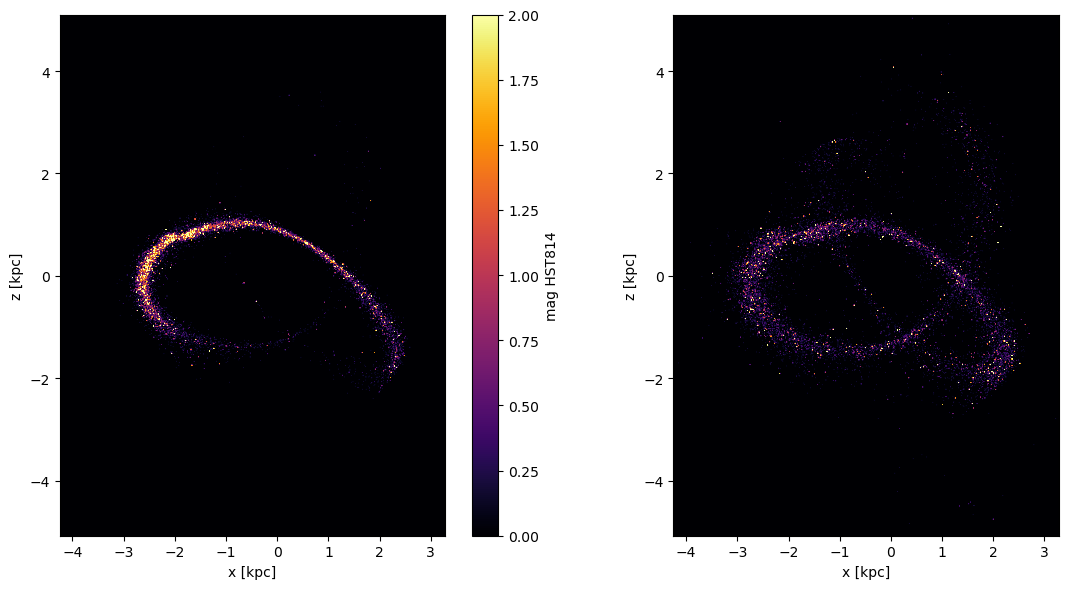

In [41]:
xrange_6 = [stars_106.x_pos.min(), stars_106.x_pos.max()]
zrange_6 = [stars_106.z_pos.min(), stars_106.z_pos.max()]
xrange_7 = [stars_107.x_pos.min(), stars_107.x_pos.max()]
zrange_7 = [stars_107.z_pos.min(), stars_107.z_pos.max()]
xrange_5 = [stars_105.x_pos.min(), stars_105.x_pos.max()]
zrange_5 = [stars_105.z_pos.min(), stars_105.z_pos.max()]


fig, ax = plt.subplots(1,2, figsize=(12, 6))
#im = ax[0].imshow(mag_grid_814_6, origin='lower', cmap='inferno_r', extent=[xrange_6[0], xrange_6[1], zrange_6[0], zrange_6[1]], vmax=36)
#ax[1].imshow(mag_grid_814_7, origin='lower', cmap='inferno_r', extent=[xrange_7[0], xrange_7[1], zrange_7[0], zrange_7[1]], vmax=36)
im = ax[0].imshow(flux_grid_814_6, origin='lower', cmap='inferno', extent=[xrange_6[0], xrange_6[1], zrange_6[0], zrange_6[1]], vmax=2)
ax[1].imshow(flux_grid_814_7, origin='lower', cmap='inferno', extent=[xrange_7[0], xrange_7[1], zrange_7[0], zrange_7[1]], vmax=2)
ax[1].sharex(ax[0])
ax[1].sharey(ax[0])
ax[0].set_xlabel('x [kpc]')
ax[0].set_ylabel('z [kpc]')
ax[1].set_xlabel('x [kpc]')
ax[1].set_ylabel('z [kpc]')

plt.colorbar(im, label='mag HST814')
plt.tight_layout()

In [43]:
hst_wfc3_f555w_psf_model = download_psf_model(psfs_dir, 'WFC3UV', 'F555W')
hst_wfc3_f814w_psf_model = download_psf_model(psfs_dir, 'WFC3UV', 'F814W')
hdulpsf_555 = fits.open(psfs_dir+hst_wfc3_f555w_psf_model, ignore_missing_end=True)
hdulpsf_814 = fits.open(psfs_dir+hst_wfc3_f814w_psf_model, ignore_missing_end=True)
hdulpsf_555.info()

Validation complete, the PSF file is readable.
Validation complete, the PSF file is readable.
Filename: /Users/lkb234/Library/CloudStorage/OneDrive-UniversityofCopenhagen/GC_stream_9050dw/Dataanalysis/psfs/STDPSF_WFC3UV_F555W.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (101, 101, 56)   float32   


        Use textwrap.indent() instead. [astropy.io.fits.hdu.hdulist]
    Header size is not multiple of 2880: 1
There may be extra bytes after the last HDU or the file is corrupted. [astropy.io.fits.hdu.hdulist]


Note that we would rather convolve with the tile that represents the stream, than that which represents where we will be injecting the stars, since we are interested in comparing with the observed feature and not in how this feature would exactly look in a different place in the image. And it really doesn't matter, they are close enough to identical for our purposes.

17.023666 16.976849


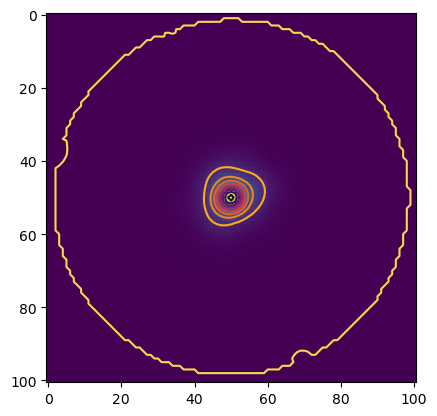

In [44]:
tile = 38 # all stream stars are approximately in tile 39 in the detector. 
plt.imshow(hdulpsf_555[0].data[tile])
cont = plt.contour(hdulpsf_555[0].data[tile], levels=10, cmap='inferno_r')
print(np.sum(hdulpsf_555[0].data[tile]), np.sum(hdulpsf_814[0].data[tile]))

In [48]:
# the pdf is oversampled by a factor of 4, so we need to downsample it to match our pixel scale
from astropy.nddata import block_reduce
downsampled_psf555 = block_reduce(hdulpsf_555[0].data[tile], (4,4), func=np.sum)
downsampled_psf814 = block_reduce(hdulpsf_814[0].data[tile], (4,4), func=np.sum)


In [47]:
PSF_555 = hdulpsf_555[0].data[tile]/np.sum(hdulpsf_555[0].data[tile]) #normalise the psf
PSF_814 = hdulpsf_814[0].data[tile]/np.sum(hdulpsf_814[0].data[tile])

mock_5_814 = convolve2d(flux_grid_814_5, downsampled_psf814/np.sum(downsampled_psf814), mode='same')
mock_6_814 = convolve2d(flux_grid_814_6, downsampled_psf814/np.sum(downsampled_psf814), mode='same')
mock_7_814 = convolve2d(flux_grid_814_7, downsampled_psf814/np.sum(downsampled_psf814), mode='same')

mock_5_555 = convolve2d(flux_grid_555_5, downsampled_psf555/np.sum(downsampled_psf555), mode='same')
mock_6_555 = convolve2d(flux_grid_555_6, downsampled_psf555/np.sum(downsampled_psf555), mode='same')
mock_7_555 = convolve2d(flux_grid_555_7, downsampled_psf555/np.sum(downsampled_psf555), mode='same')

#add background noise if injecting into empty plot. In real data, the background is already there
#noise_5 = np.random.poisson(size=mock_5_814.shape)
#mock_5_noisy = mock_5_814 + noise_5
#noise_6 = np.random.poisson(size=mock_6_814.shape)
#mock_6_noisy = mock_6_814 + noise_6
#noise_7 = np.random.poisson(size=mock_7_814.shape)
#mock_7_noisy = mock_7_814 + noise_7

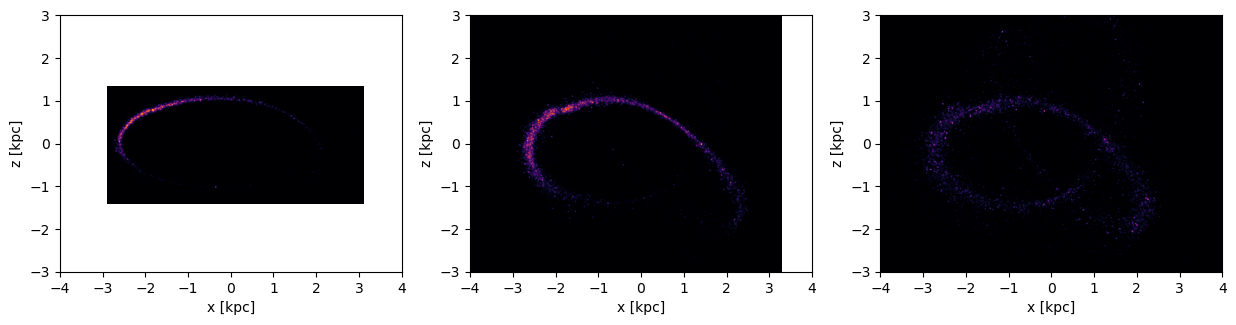

In [45]:
mockfig, mockax = plt.subplots(1, 3, figsize=(15, 6))
mockax[0].imshow(mock_5_555, origin='lower', aspect=1, cmap='inferno', vmin = 0, vmax=2, extent=[xrange_5[0], xrange_5[1], zrange_5[0], zrange_5[1]])
mockax[1].imshow(mock_6_555, origin='lower', aspect=1, cmap='inferno', vmin = 0, vmax=2, extent=[xrange_6[0], xrange_6[1], zrange_6[0], zrange_6[1]])
mockax[2].imshow(mock_7_555, origin='lower', aspect=1, cmap='inferno', vmin = 0, vmax=2, extent=[xrange_7[0], xrange_7[1], zrange_7[0], zrange_7[1]])

for i in range(3):
    mockax[i].set_xlabel('x [kpc]')
    mockax[i].set_ylabel('z [kpc]')
    mockax[i].set_xlim(-4,4)
    mockax[i].set_ylim(-3,3)

In [49]:
from acstools import acszpt
def WFC_unit_conv(image, filt, date ='2022-09-11', output='VEGAmag'):
    """
    Converts image values from cps to magnitudes using the HST conversion parameters.
    Since it uses active Query, this function needs internet connection to work. 

    Args
    - image is the image needed to be converted.
    - filt is filter name as string, eg 'F555W'. 
    - date is string in format 'yyyy-mm-dd'
    - output is the desired output units, either 'flux_density', or 'STmag', 'ABmag', or 'VEGAmag' for magnitudes.
        Flux density will be given in erg/s/cm^2/Angstrom.

    Returns
    - image with values in desired units.
    """
    q = acszpt.Query(date=date, detector='WFC', filt=filt)
    filter_zpt = q.fetch()
    if output == 'flux_density':
        F_lambda = image * u.electron/u.s * filter_zpt['PHOTFLAM']
        return F_lambda.value
    else:
        m = -2.5 * np.log10(image) + filter_zpt[output][0].value
        return m


In [52]:
from astropy import wcs

#  loading the two image files from ACS F555W and ACS F814W
filename555= '../Data_HST/hst_16890_03_acs_wfc_f555w_jesd03'
hdu_f555w = fits.open(filename555+'_drc.fits')
im555 = fits.getdata(filename555+'_drc.fits')
im555[np.isnan(im555)] = 1e-10


filename814= '../Data_HST/hst_16890_03_acs_wfc_f814w_jesd03'
hdu_f814w = fits.open(filename814+'_drc.fits')
im814 = fits.getdata(filename814+'_drc.fits')
im814[np.isnan(im814)] = 1e-10

# converting from cps to magnitudes
magim814 = WFC_unit_conv(im814, filt='F814W', output='VEGAmag')
magim555 = WFC_unit_conv(im555, filt='F555W', output='VEGAmag')

wcs_HST = wcs.WCS(hdu_f555w[1].header)

/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_4044/2876516124.py:22: RuntimeWarning: invalid value encountered in log10
  m = -2.5 * np.log10(image) + filter_zpt[output][0].value
/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_4044/2876516124.py:22: RuntimeWarning: invalid value encountered in log10
  m = -2.5 * np.log10(image) + filter_zpt[output][0].value


In [53]:
from scipy.ndimage import gaussian_filter

In [54]:
dw_mult = 5 #how much to multiply dwarf with to make visible
rel_flux_814 = 10**(-0.4*(magim814-d_mod_dw))
rel_flux_555 = 10**(-0.4*(magim555-d_mod_dw))
new5_flux814 = rel_flux_814.copy()
new6_flux814 = rel_flux_814.copy()
new7_flux814 = rel_flux_814.copy()
new710_flux814 = rel_flux_814.copy()

new5_flux555 = rel_flux_555.copy()
new6_flux555 = rel_flux_555.copy()
new7_flux555 = rel_flux_555.copy()
new710_flux555 = rel_flux_555.copy()

l_s, w_s = 2820, 2150 #placement of stream - since span of particles are different, these are set individually for the three mocks
new5_flux814[l_s:l_s+mock_5_814.shape[0], w_s:w_s+mock_5_814.shape[1]] += mock_5_814
new5_flux555[l_s:l_s+mock_5_555.shape[0], w_s:w_s+mock_5_555.shape[1]] += mock_5_555

l_s, w_s = 2420, 2010
new6_flux814[l_s:l_s+mock_6_814.shape[0], w_s:w_s+mock_6_814.shape[1]] += mock_6_814
new6_flux555[l_s:l_s+mock_6_555.shape[0], w_s:w_s+mock_6_555.shape[1]] += mock_6_555

l_s, w_s = 1940, 1700
new7_flux814[l_s:l_s+mock_7_814.shape[0], w_s:w_s+mock_7_814.shape[1]] += mock_7_814
new7_flux555[l_s:l_s+mock_7_555.shape[0], w_s:w_s+mock_7_555.shape[1]] += mock_7_555

new710_flux814[l_s:l_s+mock_7_814.shape[0], w_s:w_s+mock_7_814.shape[1]] += mock_7_814*dw_mult
new710_flux555[l_s:l_s+mock_7_555.shape[0], w_s:w_s+mock_7_555.shape[1]] += mock_7_555*dw_mult


new5_magim814 = -2.5 * np.log10(new5_flux814)+d_mod_dw 
new6_magim814 = -2.5 * np.log10(new6_flux814)+d_mod_dw
new7_magim814 = -2.5 * np.log10(new7_flux814)+d_mod_dw
new710_magim814 = -2.5 * np.log10(new710_flux814)+d_mod_dw
new5_magim555 = -2.5 * np.log10(new5_flux555)+d_mod_dw
new6_magim555 = -2.5 * np.log10(new6_flux555)+d_mod_dw
new7_magim555 = -2.5 * np.log10(new7_flux555)+d_mod_dw
new710_magim555 = -2.5 * np.log10(new710_flux555)+d_mod_dw


In [55]:
from astropy.visualization import AsinhStretch, make_rgb, AsymmetricPercentileInterval

In [56]:
def plot_rgb(ax, new_flux814, new_flux555, r_up=98, r_low=85, b_up=98, b_low=85, stretch = AsinhStretch(.3), s=2):
    g_up = np.mean([r_up, b_up])
    g_low = np.mean([r_low, b_low])
    #lupton = make_rgb(new_flux814, np.mean([new_flux814,new_flux555], axis=0),new_flux555, interval = np.array([AsymmetricPercentileInterval(r_low, r_up),AsymmetricPercentileInterval(g_low, g_up),AsymmetricPercentileInterval(b_low, b_up)])
    #                  , stretch = stretch
    #                  )
    lupton_s = make_rgb(gaussian_filter(new_flux814,1), np.mean([gaussian_filter(new_flux814,1),gaussian_filter(new_flux555,1)], axis=0),gaussian_filter(new_flux555,1), 
                    interval = np.array([AsymmetricPercentileInterval(90, 98),AsymmetricPercentileInterval(90, 98),AsymmetricPercentileInterval(90, 98)])
                  , stretch = stretch
                  )
    ax.imshow(gaussian_filter(lupton_s, (3,3,0)))
    #ax.imshow(gaussian_filter(lupton, (s,s,0))) #last index affects the colour

/opt/anaconda3/lib/python3.12/site-packages/astropy/visualization/basic_rgb.py:153: RuntimeWarning: invalid value encountered in cast
  return image_rgb.astype(output_dtype)


240.0


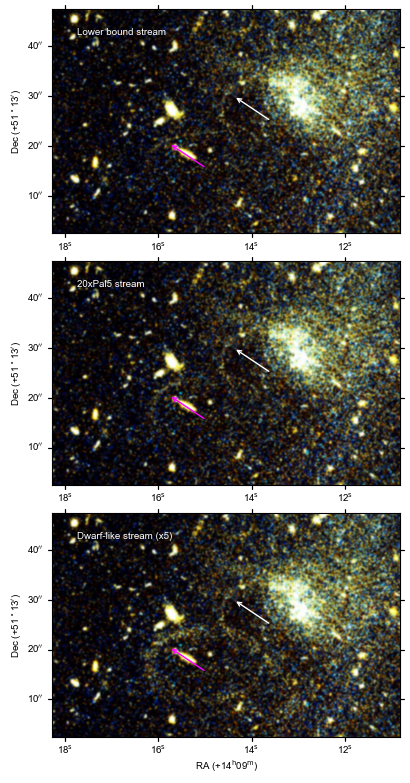

In [86]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
})
fig, axs = plt.subplots(3,1, figsize=(120/25.4, 120/25.4*2), subplot_kw={'projection': wcs_HST})

ax = axs.flatten()

dec_ref_arcsec = (51 * u.deg + 13 * u.arcmin).to_value(u.arcsec)
ra_ref_seconds = (14 + 9 / 60) * 3600

def dec_offset_formatter(values, spacing=None):
    # values are world-coordinate Dec tick locations from WCSAxes.
    if hasattr(values, 'to_value'):
        vals_arcsec = np.atleast_1d(values.to_value(u.arcsec))
    else:
        vals_arcsec = np.atleast_1d(np.asarray(values, dtype=float))
    return [f"{v - dec_ref_arcsec:.0f}"+r"$^{\prime\prime}$" for v in vals_arcsec]

def ra_offset_formatter(values, spacing=None):
    # values are world-coordinate RA tick locations from WCSAxes.
    # Show only the offset in seconds relative to 14h09m.
    if hasattr(values, 'to_value'):
        vals_seconds = np.atleast_1d(values.to_value(u.hourangle) * 3600)
    else:
        # WCSAxes RA values are usually in degrees when passed as plain floats.
        vals_seconds = np.atleast_1d(np.asarray(values, dtype=float) * 240.0)
    return [f"{v - ra_ref_seconds:.0f}"+r"$^{\mathrm{s}}$" for v in vals_seconds]

for i in range(3):
    ax[i].set_xlim(1800, 3200)
    ax[i].set_ylim(2700, 3600)

    # Keep 51deg13arcmin in the y label and show only offset arcsec in ticks.
    ax[i].coords[1].set_axislabel(r'Dec (+51$^\circ$13$^\prime$)')
    ax[i].coords[1].set_major_formatter(dec_offset_formatter)

    ax[i].tick_params(axis='both', colors='k', labelcolor='k', direction='out', length=3)
    if i != 2:
        ax[i].coords[0].set_axislabel(' ', visible=False)
        ax[i].coords[0].set_major_formatter(ra_offset_formatter)


# Keep 14h09m in the x label and show only offset seconds in ticks.    
ax[2].coords[0].set_axislabel(r'RA (+14$^\mathrm{h}$09$^\mathrm{m}$)')
ax[2].coords[0].set_major_formatter(ra_offset_formatter)




plot_rgb(ax[0], new5_flux814, new5_flux555, s=4)
#ax[1].set_title('Mock stream with 1e5 M_sun x 5')
plot_rgb(ax[1], new6_flux814, new6_flux555, s=4)
#ax[0].set_title('Mock stream with 1e6 M_sun x 2')
plot_rgb(ax[2], new710_flux814, new710_flux555, s=4)
#ax[2].set_title('Mock stream with 1e7 M_sun x 10')

arrow_specs = [
    ((2420, 2960), (2270, 3060)),
    ((2680, 3150), (2530, 3250)),
]
colors = ['magenta', 'white']
texts = ['Lower bound stream', '20xPal5 stream', f"Dwarf-like stream (x{dw_mult})"]
ax[0].text(1900, 3500, texts[0], color='w')
ax[1].text(1900, 3500, texts[1], color='w')
ax[2].text(1900, 3500, texts[2], color='w')

for i, a in enumerate(ax):
    for start, end in arrow_specs:
        a.annotate('', xy=end, xytext=start,
                   arrowprops=dict(arrowstyle='->', color=colors[arrow_specs.index((start, end))], lw=1))

# set vertical spacing to 5 mm between panels
desired_mm = 10
nrows = 3
fig_height_mm = fig.get_size_inches()[1] * 25.4
hspace = (desired_mm * nrows) / fig_height_mm
print(fig_height_mm)
fig.subplots_adjust(hspace=hspace)
#plt.savefig('Figures/mock_streams_rgb_vertical_pop.png', dpi=600)
plt.savefig('../Figures/mock_streams_formatted_120mm.eps', dpi=600)


/opt/anaconda3/lib/python3.12/site-packages/astropy/visualization/basic_rgb.py:153: RuntimeWarning: invalid value encountered in cast
  return image_rgb.astype(output_dtype)


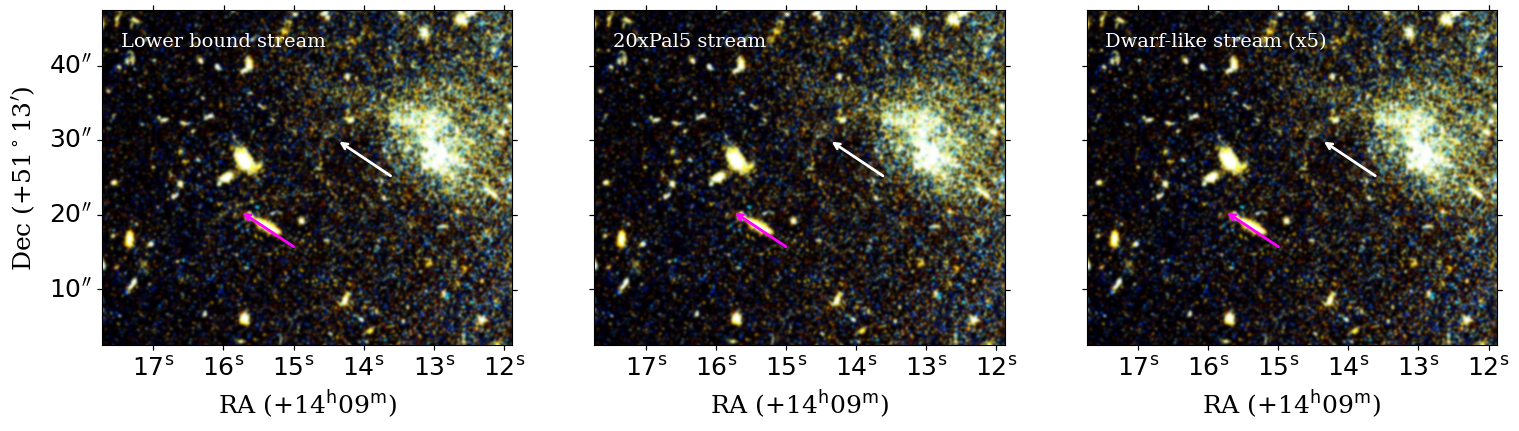

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(120/25.4, 120/25.4/3), subplot_kw={'projection': wcs_HST})

ax = axs.flatten()


def dec_offset_formatter(values, spacing=None):
    # values are world-coordinate Dec tick locations from WCSAxes.
    if hasattr(values, 'to_value'):
        vals_arcsec = np.atleast_1d(values.to_value(u.arcsec))
    else:
        vals_arcsec = np.atleast_1d(np.asarray(values, dtype=float))
    return [f"{v - dec_ref_arcsec:.0f}"+r"$^{\prime\prime}$" for v in vals_arcsec]

def ra_offset_formatter(values, spacing=None):
    # values are world-coordinate RA tick locations from WCSAxes.
    # Show only the offset in seconds relative to 14h09m.
    if hasattr(values, 'to_value'):
        vals_seconds = np.atleast_1d(values.to_value(u.hourangle) * 3600)
    else:
        # WCSAxes RA values are usually in degrees when passed as plain floats.
        vals_seconds = np.atleast_1d(np.asarray(values, dtype=float) * 240.0)
    return [f"{v - ra_ref_seconds:.0f}"+r"$^{\mathrm{s}}$" for v in vals_seconds]

for i in range(3):
    ax[i].set_xlim(1900, 3000)
    ax[i].set_ylim(2700, 3600)

    # Keep 14h09m in the x label and show only offset seconds in ticks.
    ax[i].coords[0].set_axislabel(r'RA (+14$^\mathrm{h}$09$^\mathrm{m}$)')
    ax[i].coords[0].set_major_formatter(ra_offset_formatter)


    ax[i].tick_params(axis='both', colors='k')
    if i != 0:
        ax[i].coords[1].set_ticklabel_visible(False)
ax[0].coords[1].set_axislabel(r'Dec (+51$^\circ$13$^\prime$)')
ax[0].coords[1].set_major_formatter(dec_offset_formatter)

plot_rgb(ax[0], new5_flux814, new5_flux555, s=3)
#ax[1].set_title('Mock stream with 1e5 M_sun x 5')
plot_rgb(ax[1], new6_flux814, new6_flux555, s=3)
#ax[0].set_title('Mock stream with 1e6 M_sun x 2')
plot_rgb(ax[2], new710_flux814, new710_flux555, s=3)
#ax[2].set_title('Mock stream with 1e7 M_sun x 10')

arrow_specs = [
    ((2420, 2960), (2270, 3060)),
    ((2680, 3150), (2530, 3250)),
]
colors = ['magenta', 'white']
texts = ['Lower bound stream', '20xPal5 stream', f"Dwarf-like stream (x{dw_mult})"]
ax[0].text(1950, 3500, texts[0], color='w')
ax[1].text(1950, 3500, texts[1], color='w')
ax[2].text(1950, 3500, texts[2], color='w')

for i, a in enumerate(ax):
    for start, end in arrow_specs:
        a.annotate('', xy=end, xytext=start,
                   arrowprops=dict(arrowstyle='->', color=colors[arrow_specs.index((start, end))], lw=1))
#plot_rgb(ax[3], new7_flux814, new7_flux555, s=3)
#ax[3].set_title('Mock stream with 1e7 M_sun x 1')

#plt.tight_layout()
#plt.savefig('Figures/mock_streams_rgb_horisontal_pop.pdf')
#plt.savefig('Figures/mock_streams_rgb_horisontal_pop.png', dpi=600, bbox_inches='tight')


/opt/anaconda3/lib/python3.12/site-packages/astropy/visualization/basic_rgb.py:153: RuntimeWarning: invalid value encountered in cast
  return image_rgb.astype(output_dtype)
/var/folders/6c/yf7kbvpn3wg721sk085c5d2r0000gn/T/ipykernel_65483/3482416344.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


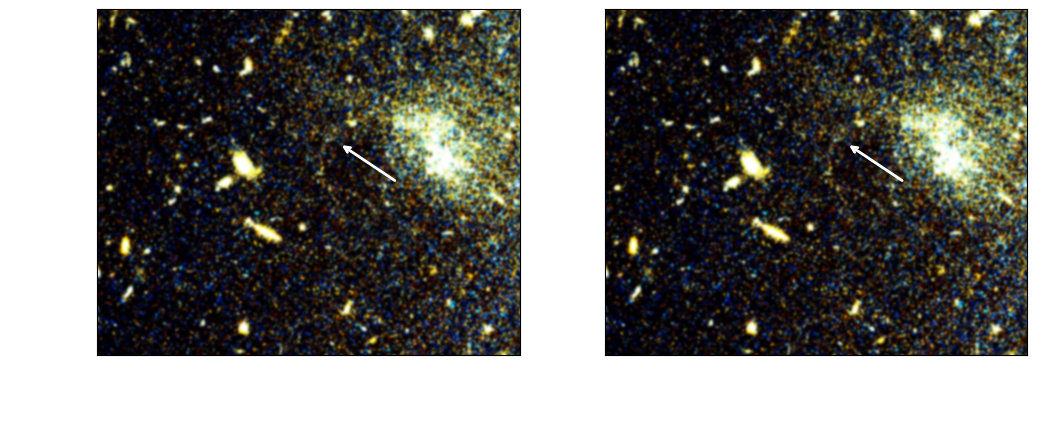

In [109]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': wcs_HST}, facecolor='none')
fig.patch.set_alpha(0.0)

ax = axs.flatten()

for i in range(2):
    ax[i].set_xlim(1900, 3000)
    ax[i].set_ylim(2700, 3600)
    ax[i].set_facecolor('none')

    # Keep 14h09m in the x label and show only offset seconds in ticks.
    ax[i].coords[0].set_axislabel(r'RA (+14$^\mathrm{h}$09$^\mathrm{m}$)', fontsize=18, fontfamily='serif', color='w')
    ax[i].coords[0].set_major_formatter(ra_offset_formatter)

    ax[i].tick_params(axis='both', colors='w', labelsize=16)
    ax[i].coords[0].set_ticklabel(color='w', size=16)
    ax[i].coords[1].set_ticklabel(color='w', size=16)

    for spine in ax[i].spines.values():
        spine.set_color('w')

    if i != 0:
        ax[i].coords[1].set_ticklabel_visible(False)

ax[0].coords[1].set_axislabel(r'Dec (+51$^\circ$13$^\prime$)', fontsize=18, fontfamily='serif', color='w')
ax[0].coords[1].set_major_formatter(dec_offset_formatter)

# 20xPal5 stream (middle panel in cell above)
plot_rgb(ax[0], new6_flux814, new6_flux555, s=3)
# Dwarf-like stream (right panel in cell above)
plot_rgb(ax[1], new710_flux814, new710_flux555, s=3)

arrow_specs = [
    ((2420, 2960), (2270, 3060)),
    ((2680, 3150), (2530, 3250)),
]
colors = ['none', 'white']
texts = ['20xPal5 stream', f"Dwarf-like stream (x{dw_mult})"]

#ax[0].text(1950, 3500, texts[0], color='w', fontsize=14, fontfamily='serif')
#ax[1].text(1950, 3500, texts[1], color='w', fontsize=14, fontfamily='serif')

for a in ax:
    for j, (start, end) in enumerate(arrow_specs):
        a.annotate('', xy=end, xytext=start,
                   arrowprops=dict(arrowstyle='->', color=colors[j], lw=2))
#ax[0].annotate('', xy=(2270, 3060), xytext=(2420, 2960),
#                   arrowprops=dict(arrowstyle='->', color='magenta', lw=2))
plt.tight_layout()
plt.savefig('Figures/mock_streams_none_trans.png', dpi=600, bbox_inches='tight', transparent=True)
